# Maker Clean — Passive-Only BBO Maker

Goal: **always BE the best bid and best offer — improving by one tick whenever possible,
joining only when improving is impossible — and never, ever take anyone's liquidity.**

## Quoting policy
- **Improve first**: target price is `best_bid + 1 tick` / `best_ask − 1 tick`. That makes us
  the sole BBO with fresh queue priority.
- **Join as fallback**: if the spread is too tight to improve without becoming marketable,
  we join the existing best level instead.
- **Never cancel a quote that is already the BBO**: if the websocket shows our resting price
  still equal to the best price, we hold — cancelling would throw away queue priority. We only
  cancel/replace when someone has strictly beaten our price.
- **Event-driven**: the loop wakes on every websocket book message and reacts immediately
  (with a 1s heartbeat fallback for housekeeping) — no polling drift.
- Price quality is deliberately NOT a consideration — the objective is BBO presence, not edge.

## Never-take guarantees

Orders are placed via `POST /v1/conductor/orders` (JWT-authenticated, same auth as every other
call in this notebook), NOT the `/v1/cefi/orders` direct endpoint. That direct endpoint is
**institutional-only** (see `openapi.json`'s own description) and requires a real HMAC secret
issued separately by TrueMarkets — it was never going to authenticate with this account's
retail EC-JWT key, which is why every order 401'd with "Authentication key is invalid" no
matter how the (guessed) HMAC secret was derived. The conductor Gateway proxies to CeFi under
the JWT that already works for balances/cancel_all, and accepts `order_type="limit"` — but it
has **no documented ALO / post-only flag**, so unlike before, the exchange does not itself
reject a marketable order on arrival. Guarantee #1 below is therefore no longer exchange-
enforced; **the never-take guarantee now rests entirely on gates #2-#7**, our own software.

1. ~~ALO / post-only~~ — **not available** on this account's order path (institutional-only
   endpoint, see above). Not enforced by the exchange; rely on the guards below instead.
2. **Cross guard** — bid is never sent unless ≥ `CROSS_GUARD_TICKS` full ticks below the live
   ask; ask is never sent unless ≥ `CROSS_GUARD_TICKS` ticks above the live bid.
3. **Freshness gate** — nothing is sent if the TM book hasn't ticked within `MAX_BOOK_AGE_SECS`
   or the feed is disconnected; quotes are pulled if the feed stays dead.
4. **Crossed-book gate** — nothing is sent while `best_bid >= best_ask`.
5. **Sanity gate** — nothing is sent (and quotes are pulled) while the TM mid deviates more
   than `MAX_CB_DEVIATION` from the Coinbase mid.
6. **Last-instant recheck** — `place_passive_limit()` re-validates freshness, crossing, tick
   alignment, price-string round-trip and exact 0.0004 size against the *live* book immediately
   before the HTTP call, else refuses.
7. **Self-cross guard** — new bid must rest ≥ 1 tick below our own resting ask (and vice versa).
8. **Cancel-confirm** — a side is only requoted once the previous order is confirmed dead.
9. **Ghost-order detection** — if the book stops showing our posted price or an order has rested
   unverified for 60s, its status is re-checked against the exchange.
10. **Rate-limit reserve** — no order is placed when the remaining request budget couldn't cancel it.
11. **Exit hygiene** — kill switch, exceptions and kernel interrupts cancel every order on exit.

Order size is **exactly 0.0004 BTC for every order, both sides**.

**Priority when goals conflict: never-take > BBO presence.** Since guarantee #1 is now
software-only rather than exchange-enforced, consider raising `CROSS_GUARD_TICKS` above its
default of 1 if you want more margin against a stale-book race actually crossing the spread.

In [1]:
import sys
import os
import asyncio
import math
import time
import json
from pathlib import Path

ROOT_DIR = Path(os.getcwd()).parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import aiohttp
import websockets
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from dotenv import load_dotenv

from lib.execution import ExecutionClient
from lib.coinbase_feed import CoinbaseBookA

load_dotenv(ROOT_DIR / 'keys' / '.env')

TM_REST_URL = os.getenv('BASE_REST_URL', 'https://api.truemarkets.co')
TM_KEY_FILE = str(ROOT_DIR / 'keys' / 'truemarkets-api-key-edd1691b.json')
CB_WS_URL   = os.getenv('COINBASE_WS_URL', 'wss://ws-feed.exchange.coinbase.com')
CB_PRODUCT  = 'BTC-USD'
BASE_ASSET  = 'BTC'
QUOTE_ASSET = 'USDC'

In [2]:
class TrueMarketsBook:
    _WS_URL = 'wss://api.truex.co/api/v1'
    _HEADERS = {
        'Origin': 'https://truemarkets.co',
        'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36',
        'Accept-Language': 'en-US,en;q=0.9',
    }
    _SNAPSHOT_TIMEOUT = 6.0   # a healthy node sends a two-sided SNAPSHOT within this; else it's bad
    _NODE_CYCLE_SECS  = 0.5   # fast redial to cycle the load balancer to another backend node

    def __init__(self, symbol='BTC-PYUSD'):
        self.symbol    = symbol
        self._bids     = {}
        self._asks     = {}
        self._ready    = False
        self._last_msg = None            # wall-clock time of last websocket message
        self.updated   = asyncio.Event() # set on every book change - lets the strategy react instantly

    @property
    def best_bid(self):      return max(self._bids) if self._bids else None
    @property
    def best_ask(self):      return min(self._asks) if self._asks else None
    @property
    def best_bid_size(self):
        b = self.best_bid; return self._bids[b] if b is not None else None
    @property
    def best_ask_size(self):
        a = self.best_ask; return self._asks[a] if a is not None else None
    @property
    def mid(self):
        b, a = self.best_bid, self.best_ask
        return (b + a) / 2.0 if (b is not None and a is not None) else None
    @property
    def is_ready(self): return self._ready
    @property
    def age(self):
        """Seconds since the last websocket message, or None if never connected."""
        return (time.time() - self._last_msg) if self._last_msg else None

    def _handle_snapshot(self, data):
        self._bids  = {float(b['price']): float(b['qty']) for b in data.get('bids', []) if float(b['qty']) > 0}
        self._asks  = {float(a['price']): float(a['qty']) for a in data.get('asks', []) if float(a['qty']) > 0}
        self.updated.set()

    def _handle_update(self, data):
        for b in data.get('bids', []):
            p, q = float(b['price']), float(b['qty'])
            if q == 0: self._bids.pop(p, None)
            else:      self._bids[p] = q
        for a in data.get('asks', []):
            p, q = float(a['price']), float(a['qty'])
            if q == 0: self._asks.pop(p, None)
            else:      self._asks[p] = q
        self.updated.set()

    async def run(self):
        """Connect, subscribe, and stream the book - self-healing across a load
        balancer whose backend nodes are only ~1-in-4 healthy.

        A bad node answers the subscribe with {status: ERROR} (or just goes
        silent) and never sends a book, so the OLD code hung forever on it. Here
        we treat ERROR / no-snapshot-within-timeout as a failed connection and
        redial fast, cycling nodes until one streams a real two-sided snapshot.
        """
        bad_streak = 0
        while True:
            healthy = False
            try:
                async with websockets.connect(self._WS_URL, additional_headers=self._HEADERS) as ws:
                    self._ready = False
                    await ws.send(json.dumps({
                        'type': 'SUBSCRIBE_NO_AUTH',
                        'item_names': [self.symbol],
                        'channels': ['DEPTH'],
                        'timestamp': str(int(time.time())),
                    }))
                    sub_deadline = time.time() + self._SNAPSHOT_TIMEOUT
                    while True:
                        # while not yet healthy, cap the wait so a silent bad node
                        # can't stall us; once streaming, block indefinitely.
                        if healthy:
                            timeout = None
                        else:
                            timeout = sub_deadline - time.time()
                            if timeout <= 0:
                                break             # bad/silent node - redial
                        try:
                            raw = await asyncio.wait_for(ws.recv(), timeout=timeout)
                        except asyncio.TimeoutError:
                            break                 # bad/silent node - redial
                        self._last_msg = time.time()
                        try: msg = json.loads(raw)
                        except Exception: continue
                        if msg.get('status') == 'ERROR':
                            break                 # bad LB node - redial to land elsewhere
                        upd = msg.get('update')
                        d   = msg.get('data', {})
                        if upd == 'SNAPSHOT':
                            self._handle_snapshot(d)
                            if self._bids and self._asks:   # a REAL two-sided book
                                healthy = True
                                self._ready = True
                                if bad_streak:
                                    print(f'TM feed: healthy node after {bad_streak} bad node(s)')
                                bad_streak = 0
                        elif upd == 'UPDATE':
                            self._handle_update(d)
            except websockets.ConnectionClosed:
                pass
            except Exception as e:
                print(f'TrueMarketsBook error: {e}')
            self._ready = False
            self.updated.set()   # wake the strategy so it notices the outage immediately
            if not healthy:
                bad_streak += 1
                if bad_streak == 1 or bad_streak % 10 == 0:
                    print(f'TM feed: bad/ERROR node, cycling load balancer (attempt {bad_streak})...')
            # redial fast while cycling nodes; brief pause after a real stream drop
            await asyncio.sleep(self._NODE_CYCLE_SECS if not healthy else 1.0)

### Parameters

In [3]:
QUOTE_SIZE_BTC        = 0.0004   # EVERY order, both sides, is exactly this size
TICK_SIZE             = 0.1
PRICE_DECIMALS        = 1
IDLE_TICK_SECS        = 1.0      # heartbeat when the websocket is quiet (housekeeping only)

# ── CeFi instrument id for the new /v1/cefi/orders endpoint ─────────────────
CEFI_INSTRUMENT_ID    = 'BTC-PYUSD'   # adjust if TrueMarkets uses a different symbol format

# ── never-take safety gates ──────────────────────────────────────────────────
CROSS_GUARD_TICKS     = 1        # min full ticks between our price and the live opposite touch.
                                 # 1 = strictly inside/at the touch, never marketable vs the book
                                 # we see. Raise to 2 to also absorb a 1-tick in-flight move,
                                 # at the cost of standing down when the spread is <= 2 ticks.
MAX_BOOK_AGE_SECS     = 10.0     # book with no tick in this long is untrusted: no new orders
PULL_QUOTES_AFTER_SECS= 30.0     # feed dead this long -> cancel resting quotes entirely
MAX_CB_DEVIATION      = 0.01     # TM mid vs Coinbase mid sanity bound (1%): no orders + pull quotes
RL_RESERVE            = 6        # keep this many requests in reserve so a cancel is always possible
REPRICE_MIN_SECS      = 1.0      # per-side cancel/replace cooldown (rate-limit protection)
ORDER_VERIFY_SECS     = 60.0     # re-verify long-lived resting orders against the exchange
GHOST_GRACE_SECS      = 3.0      # let the feed catch up after placing before "missing" checks
GHOST_CHECK_MIN_SECS  = 5.0      # min gap between missing-from-book status checks

# ── risk limits ──────────────────────────────────────────────────────────────
MAX_POSITION_BTC      = 0.002
DAILY_LOSS_LIMIT      = 5.0
BALANCE_POLL_SECS     = 4.0      # balance/fill reconciliation cadence (saves rate limit)
PLOT_EVERY_SECS       = 5.0
STATUS_EVERY_SECS     = 1.0
TM_BOOK_SYMBOL        = 'BTC-PYUSD'

# order statuses that mean "still live on the exchange"
# includes both conductor and CeFi (/v1/cefi/orders) status strings
LIVE_STATUSES = {
    # conductor
    'pending', 'active', 'open', 'new', 'partially_filled',
    # CeFi (INITIALIZED NEW_PENDING ACTIVE MODIFY_PENDING = still live)
    'INITIALIZED', 'NEW_PENDING', 'ACTIVE', 'MODIFY_PENDING',
}

### Helpers

In [4]:
size_str = f'{QUOTE_SIZE_BTC:.8f}'.rstrip('0').rstrip('.')
assert size_str == '0.0004', f'order size must be exactly 0.0004, got {size_str}'

def fmt_px(p): return f'{p:.{PRICE_DECIMALS}f}'

def floor_tick(p): return math.floor(p / TICK_SIZE + 1e-9) * TICK_SIZE
def ceil_tick(p):  return math.ceil (p / TICK_SIZE - 1e-9) * TICK_SIZE


async def cancel_confirmed(bot, session, oid):
    """True only when the order is CONFIRMED no longer live.

    A swallowed cancel failure must never free a slot — that is how duplicate
    orders (and untracked inventory) happen. If the cancel is not acknowledged,
    fall back to reading the order status; anything unknown counts as live.
    Uses the conductor cancel_order / get_order_status (JWT-authenticated) —
    see the note on place_passive_limit for why this replaced the /v1/cefi/*
    HMAC endpoints."""
    if not oid:
        return True
    try:
        if await bot.cancel_order(session, oid):
            return True
    except Exception:
        pass
    try:
        st = await bot.get_order_status(session, oid)
    except Exception:
        return False
    if st is None:
        return False
    return st not in LIVE_STATUSES


async def place_passive_limit(bot, session, tm_book, side, px):
    """The ONLY order-placement path. Re-validates everything against the live
    book at the last possible instant and refuses anything that could take.

    Sends via POST /v1/conductor/orders (JWT auth), NOT /v1/cefi/orders. The
    /v1/cefi/* direct endpoint is institutional-only (see openapi.json) and
    was 401'ing every order ("Authentication key is invalid") because there is
    no real HMAC secret to derive for a retail EC-JWT key — the previous code
    guessed one from the private key scalar, which can never authenticate.
    The conductor Gateway proxies to CeFi under the same JWT this notebook
    already uses successfully for balances/cancel_all, and accepts
    order_type="limit" with a price. It has no documented ALO/post-only flag,
    so the exchange no longer rejects a marketable order for us — guarantee #1
    in the header cell is now enforced ONLY by our own cross-guard checks
    below (#2-#7), not by the exchange. Keep CROSS_GUARD_TICKS conservative.

    Returns (order, refusal_reason) — exactly one of the two is set."""
    if abs(QUOTE_SIZE_BTC - 0.0004) > 1e-12:
        return None, 'size drifted from 0.0004'
    if abs(px - round(px / TICK_SIZE) * TICK_SIZE) > 1e-6:
        return None, f'price {px} not tick-aligned'
    px_str = fmt_px(px)
    if abs(float(px_str) - px) > 1e-6:
        return None, f'price string {px_str} != {px}'
    if not tm_book.is_ready or tm_book.age is None or tm_book.age > MAX_BOOK_AGE_SECS:
        return None, 'book stale at send time'
    lb, la = tm_book.best_bid, tm_book.best_ask
    if lb is None or la is None or lb >= la:
        return None, 'book empty/crossed at send time'
    guard = CROSS_GUARD_TICKS * TICK_SIZE
    if side == 'buy':
        if px > la - guard + 1e-9:
            return None, f'bid {px_str} within {CROSS_GUARD_TICKS} tick(s) of ask {la:.1f}'
    elif side == 'sell':
        if px < lb + guard - 1e-9:
            return None, f'ask {px_str} within {CROSS_GUARD_TICKS} tick(s) of bid {lb:.1f}'
    else:
        return None, f'bad side {side!r}'
    order = await bot.place_order(
        session,
        BASE_ASSET,
        QUOTE_ASSET,
        side='buy' if side == 'buy' else 'sell',
        qty=size_str,
        qty_unit='base',
        order_type='limit',
        price=px_str,
    )
    return order, None


async def get_full_balances(bot, session):
    data = await bot._get(session, '/v1/conductor/balances')
    total_btc = avail_btc = total_usd = avail_usd = 0.0
    if not data:
        return None, None, None, None
    for b in data.get('data', []):
        sym   = b.get('symbol', '')
        avail = float(b.get('available', 0) or 0)
        held  = float(b.get('held',      0) or 0)
        if sym == BASE_ASSET:
            total_btc += avail + held
            avail_btc += avail
        elif sym in (QUOTE_ASSET, 'PYUSD'):
            total_usd += avail + held
            avail_usd += avail
    return total_btc, total_usd, avail_btc, avail_usd

# ── chart series ─────────────────────────────────────────────────────────────
time_series    = []
pnl_series     = []
vol_series     = []
inv_series     = []
our_bid_series = []
our_ask_series = []

def _cumsum(vals):
    out, s = [], 0.0
    for v in vals:
        s += v; out.append(s)
    return out

def update_plot(tm_book=None):
    clear_output(wait=True)
    fig, axes = plt.subplots(4, 1, figsize=(12, 16))
    ax1, ax2, ax3, ax4 = axes

    ax1.plot(time_series, pnl_series, color='green', label='Session PnL ($)')
    ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax1.axhline(-DAILY_LOSS_LIMIT, color='red', linestyle='--', linewidth=1,
                label=f'Loss limit -${DAILY_LOSS_LIMIT}')
    ax1.fill_between(time_series, pnl_series, 0,
                     where=[p >= 0 for p in pnl_series], alpha=0.15, color='green')
    ax1.fill_between(time_series, pnl_series, 0,
                     where=[p <  0 for p in pnl_series], alpha=0.15, color='red')
    ax1.set_ylabel('PnL ($)'); ax1.set_title('Session PnL')
    ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

    ax2.plot(time_series, vol_series, color='blue', label='Maker volume ($)')
    ax2.fill_between(time_series, vol_series, alpha=0.12, color='blue')
    ax2.set_ylabel('Volume ($)'); ax2.set_title('Cumulative Maker Volume')
    ax2.legend(loc='upper left'); ax2.grid(True, alpha=0.3)

    ax3.plot(time_series, inv_series, color='orange', label='Net inventory (BTC)')
    ax3.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax3.axhline( MAX_POSITION_BTC, color='red', linestyle=':', alpha=0.6, label='Position limit')
    ax3.axhline(-MAX_POSITION_BTC, color='red', linestyle=':', alpha=0.6)
    ax3.set_ylabel('BTC'); ax3.set_title('Net Inventory')
    ax3.legend(loc='upper left'); ax3.grid(True, alpha=0.3)

    if tm_book is not None and tm_book.is_ready and tm_book._bids and tm_book._asks:
        sorted_bids = sorted(tm_book._bids.items(), reverse=True)
        sorted_asks = sorted(tm_book._asks.items())
        bid_px  = [p for p, _ in sorted_bids]
        bid_cum = _cumsum([q for _, q in sorted_bids])
        ask_px  = [p for p, _ in sorted_asks]
        ask_cum = _cumsum([q for _, q in sorted_asks])
        ax4.fill_between(bid_px, bid_cum, step='post', color='green', alpha=0.35, label='Bids')
        ax4.plot(bid_px, bid_cum, color='lime',   drawstyle='steps-post', linewidth=1)
        ax4.fill_between(ask_px, ask_cum, step='pre',  color='red',   alpha=0.35, label='Asks')
        ax4.plot(ask_px, ask_cum, color='salmon', drawstyle='steps-pre',  linewidth=1)
        if our_bid_series:
            ax4.axvline(our_bid_series[-1], color='lime',   linestyle='--', linewidth=1.5,
                        label=f"Our bid ${our_bid_series[-1]:.1f}")
        if our_ask_series:
            ax4.axvline(our_ask_series[-1], color='salmon', linestyle='--', linewidth=1.5,
                        label=f"Our ask ${our_ask_series[-1]:.1f}")
        mid = (bid_px[0] + ask_px[0]) / 2
        ax4.set_xlim(mid - 500, mid + 500)
    else:
        ax4.text(0.5, 0.5, 'Waiting for order book...', ha='center', va='center',
                 transform=ax4.transAxes)
    ax4.set_xlabel('Price ($)'); ax4.set_ylabel('Cumulative BTC')
    ax4.set_title('Live TrueMarkets Order Book Depth')
    ax4.legend(loc='upper right'); ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    display(fig)
    plt.close(fig)

### Strategy Loop

Per-side state machine, evaluated on every websocket event:

| Book shows | Meaning | Action |
|---|---|---|
| `best == our posted px` | we ARE the BBO | **hold** — never cancel, queue priority is sacred |
| `best` beats our posted px | someone outbid/undercut us | cancel-confirm, then improve `best ± 1 tick` (join if guard blocks improving) |
| `best` worse than our posted px | our order vanished from the book | verify status; requote if confirmed dead |
| no order on this side | slot free | place improve-first, join-fallback |

In [5]:
async def run_strategy():
    for s in [time_series, pnl_series, vol_series, inv_series, our_bid_series, our_ask_series]:
        s.clear()

    bot     = ExecutionClient(key_file=TM_KEY_FILE, base_url=TM_REST_URL)
    book_a  = CoinbaseBookA(ws_url=CB_WS_URL, product_id=CB_PRODUCT)
    tm_book = TrueMarketsBook(symbol=TM_BOOK_SYMBOL)

    feed_cb = asyncio.create_task(book_a.run())
    feed_tm = asyncio.create_task(tm_book.run())

    start_time = time.time()

    bid_oid = ask_oid = None
    bid_posted_px = ask_posted_px = None
    bid_placed_at = ask_placed_at = None
    bid_checked_at = ask_checked_at = 0.0
    bid_repriced_at = ask_repriced_at = 0.0

    initial_btc = initial_usd = None
    prev_total_btc = None
    total_btc = total_usd = avail_btc = avail_usd = 0.0
    inventory_btc = cash_usdc = maker_volume = 0.0

    last_balance_at = last_plot_at = last_print_at = 0.0

    try:
        async with aiohttp.ClientSession() as session:
            await bot.authenticate(session)
            print('Authenticated. Cancelling any pre-existing orders...')
            await bot.cancel_all(session)

            res = await get_full_balances(bot, session)
            if res[0] is None:
                raise RuntimeError('Failed to fetch initial balances')
            initial_btc, initial_usd, avail_btc, avail_usd = res
            prev_total_btc = initial_btc
            total_btc, total_usd = initial_btc, initial_usd
            print(f'Starting balances: {initial_btc:.6f} BTC  |  ${initial_usd:.2f} USDC+PYUSD')
            print('Waiting for TrueMarkets book snapshot...')

            # wait for a genuine TWO-SIDED book — is_ready flips true on the first
            # snapshot, but that snapshot can arrive with one side empty, leaving
            # best_bid/best_ask None. Requiring both sides avoids formatting None.
            while not (tm_book.is_ready and tm_book.best_bid is not None
                       and tm_book.best_ask is not None):
                await asyncio.sleep(0.2)
            print(f'TM book ready: {tm_book.best_bid:.1f} / {tm_book.best_ask:.1f}')
            print('Running event-driven — interrupt kernel to stop (all orders cancelled on exit).\n')

            while True:
                # ── 0. Wake on the next book event (or heartbeat) ─────────────
                try:
                    await asyncio.wait_for(tm_book.updated.wait(), timeout=IDLE_TICK_SECS)
                except asyncio.TimeoutError:
                    pass
                tm_book.updated.clear()
                now = time.time()

                # ── 1. Book freshness — never act on a stale/dead book ────────
                age   = tm_book.age
                fresh = tm_book.is_ready and age is not None and age <= MAX_BOOK_AGE_SECS
                if not fresh:
                    dead = (age is None) or (age > PULL_QUOTES_AFTER_SECS) or not tm_book.is_ready
                    if (bid_oid or ask_oid) and dead:
                        print(f"  {time.strftime('%H:%M:%S')}  feed dead — pulling quotes")
                        if bid_oid and await cancel_confirmed(bot, session, bid_oid):
                            bid_oid = bid_posted_px = bid_placed_at = None
                        if ask_oid and await cancel_confirmed(bot, session, ask_oid):
                            ask_oid = ask_posted_px = ask_placed_at = None
                    await asyncio.sleep(IDLE_TICK_SECS)
                    continue

                best_bid = tm_book.best_bid
                best_ask = tm_book.best_ask
                if best_bid is None or best_ask is None:
                    await asyncio.sleep(IDLE_TICK_SECS)
                    continue
                spread = best_ask - best_bid
                bid_sz = tm_book.best_bid_size or 0.0
                ask_sz = tm_book.best_ask_size or 0.0

                # ── 2. Placement gates (shared by both sides) ─────────────────
                cb_mid = book_a.mid
                tm_mid = tm_book.mid
                rl     = bot._rl_remaining

                crossed   = best_bid >= best_ask
                deviated  = bool(cb_mid and tm_mid and abs(tm_mid - cb_mid) / cb_mid > MAX_CB_DEVIATION)
                budget_ok = (rl is None) or (rl > RL_RESERVE)

                quote_gate = None
                if crossed:
                    quote_gate = f'book crossed {best_bid:.1f}/{best_ask:.1f}'
                elif deviated:
                    quote_gate = f'TM mid {tm_mid:.1f} vs CB mid {cb_mid:.1f} > {MAX_CB_DEVIATION:.1%}'
                elif not budget_ok:
                    quote_gate = f'rate budget {rl} <= reserve {RL_RESERVE}'

                # a deviating book means our resting quotes may be badly mispriced — get out
                if deviated and (bid_oid or ask_oid):
                    print(f'  ! {quote_gate} — pulling quotes')
                    if bid_oid and await cancel_confirmed(bot, session, bid_oid):
                        bid_oid = bid_posted_px = bid_placed_at = None
                    if ask_oid and await cancel_confirmed(bot, session, ask_oid):
                        ask_oid = ask_posted_px = ask_placed_at = None

                mark = cb_mid or tm_mid

                # ── 3. Balances + fill detection (time-based cadence) ─────────
                if now - last_balance_at >= BALANCE_POLL_SECS:
                    last_balance_at = now
                    res = await get_full_balances(bot, session)
                    if res[0] is not None:
                        total_btc, total_usd, avail_btc, avail_usd = res
                        delta_btc = total_btc - prev_total_btc
                        if abs(delta_btc) > 1e-8:
                            if delta_btc > 0:
                                fill_px = bid_posted_px or best_bid
                                print(f'  ✓ BID FILL +{delta_btc:.6f} BTC @ ~${fill_px:.1f}')
                            else:
                                fill_px = ask_posted_px or best_ask
                                print(f'  ✓ ASK FILL {delta_btc:.6f} BTC @ ~${fill_px:.1f}')
                            maker_volume += abs(delta_btc) * fill_px
                            # exactly one clean 0.0004 fill -> free that side only;
                            # anything else (partial / overlapping fills) -> confirm-kill
                            # both sides so no half-filled ghost order can linger
                            if abs(delta_btc - QUOTE_SIZE_BTC) < 1e-6:
                                bid_oid = bid_posted_px = bid_placed_at = None
                            elif abs(delta_btc + QUOTE_SIZE_BTC) < 1e-6:
                                ask_oid = ask_posted_px = ask_placed_at = None
                            else:
                                if bid_oid and await cancel_confirmed(bot, session, bid_oid):
                                    bid_oid = bid_posted_px = bid_placed_at = None
                                if ask_oid and await cancel_confirmed(bot, session, ask_oid):
                                    ask_oid = ask_posted_px = ask_placed_at = None
                        inventory_btc  = total_btc - initial_btc
                        cash_usdc      = total_usd - initial_usd
                        prev_total_btc = total_btc

                # ── 4. Ghost-order detection ──────────────────────────────────
                # (a) our posted price vanished from the book -> check right away
                # (b) periodic re-verification of long-lived orders
                # Uses get_order_status (conductor, JWT) — orders are now placed
                # via place_order/conductor, not the institutional-only CeFi endpoint.
                if bid_oid and bid_posted_px is not None:
                    missing = best_bid < bid_posted_px - 1e-9
                    settled = bid_placed_at and (now - bid_placed_at) > GHOST_GRACE_SECS
                    overdue = now - max(bid_placed_at or 0.0, bid_checked_at) > ORDER_VERIFY_SECS
                    if (missing and settled and now - bid_checked_at > GHOST_CHECK_MIN_SECS) or overdue:
                        st = await bot.get_order_status(session, bid_oid)
                        bid_checked_at = now
                        if st is not None and st not in LIVE_STATUSES:
                            print(f'  ! resting bid is {st} — slot freed, requoting')
                            bid_oid = bid_posted_px = bid_placed_at = None
                if ask_oid and ask_posted_px is not None:
                    missing = best_ask > ask_posted_px + 1e-9
                    settled = ask_placed_at and (now - ask_placed_at) > GHOST_GRACE_SECS
                    overdue = now - max(ask_placed_at or 0.0, ask_checked_at) > ORDER_VERIFY_SECS
                    if (missing and settled and now - ask_checked_at > GHOST_CHECK_MIN_SECS) or overdue:
                        st = await bot.get_order_status(session, ask_oid)
                        ask_checked_at = now
                        if st is not None and st not in LIVE_STATUSES:
                            print(f'  ! resting ask is {st} — slot freed, requoting')
                            ask_oid = ask_posted_px = ask_placed_at = None

                # ── 5. Targets: improve by one tick, join only if guard blocks ─
                guard = CROSS_GUARD_TICKS * TICK_SIZE
                bid_cap = best_ask - guard
                if ask_oid and ask_posted_px is not None:
                    bid_cap = min(bid_cap, ask_posted_px - TICK_SIZE)   # never cross our own ask
                our_bid  = floor_tick(min(best_bid + TICK_SIZE, bid_cap))
                bid_mode = ('improve' if our_bid > best_bid + 1e-9 else
                            'join'    if our_bid > best_bid - 1e-9 else 'blocked')

                ask_floor = best_bid + guard
                if bid_oid and bid_posted_px is not None:
                    ask_floor = max(ask_floor, bid_posted_px + TICK_SIZE)  # never cross our own bid
                our_ask  = ceil_tick(max(best_ask - TICK_SIZE, ask_floor))
                ask_mode = ('improve' if our_ask < best_ask - 1e-9 else
                            'join'    if our_ask < best_ask + 1e-9 else 'blocked')

                # ── 6. BID ────────────────────────────────────────────────────
                bid_collateral_usd = (QUOTE_SIZE_BTC * bid_posted_px) if (bid_oid and bid_posted_px) else 0.0
                bid_action = 'idle'

                if bid_oid and bid_posted_px is not None:
                    if best_bid <= bid_posted_px + 1e-9:
                        bid_action = 'hold (we are BBO)'          # never cancel the BBO — queue prio
                    elif quote_gate:
                        bid_action = f'hold ({quote_gate})'
                    elif now - bid_repriced_at < REPRICE_MIN_SECS:
                        bid_action = 'outbid — reprice cooldown'
                    elif await cancel_confirmed(bot, session, bid_oid):
                        bid_oid = bid_posted_px = bid_placed_at = None
                        bid_repriced_at = now
                        bid_action = 'outbid — repricing'
                    else:
                        bid_action = 'cancel unconfirmed — holding slot'

                if not bid_oid:
                    if quote_gate:
                        bid_action = f'skip ({quote_gate})'
                    elif bid_mode == 'blocked':
                        bid_action = f'stand down (spread {spread:.1f} below guard)'
                    elif inventory_btc + QUOTE_SIZE_BTC > MAX_POSITION_BTC + 1e-12:
                        bid_action = f'skip (max long {inventory_btc:+.5f})'
                    elif (avail_usd + bid_collateral_usd) < QUOTE_SIZE_BTC * our_bid * 1.01:
                        bid_action = 'skip (no USDC)'
                    else:
                        order, refusal = await place_passive_limit(bot, session, tm_book, 'buy', our_bid)
                        if order and order.get('order_id'):
                            bid_oid       = order['order_id']
                            bid_posted_px = our_bid
                            bid_placed_at = now
                            bid_action    = f'BUY  {size_str} @ {our_bid:.1f} ({bid_mode})'
                        elif refusal:
                            bid_action = f'refused ({refusal})'
                        else:
                            bid_action = 'BUY FAILED'

                # ── 7. ASK ────────────────────────────────────────────────────
                ask_collateral_btc = QUOTE_SIZE_BTC if ask_oid else 0.0
                ask_action = 'idle'

                if ask_oid and ask_posted_px is not None:
                    if best_ask >= ask_posted_px - 1e-9:
                        ask_action = 'hold (we are BBO)'          # never cancel the BBO — queue prio
                    elif quote_gate:
                        ask_action = f'hold ({quote_gate})'
                    elif now - ask_repriced_at < REPRICE_MIN_SECS:
                        ask_action = 'undercut — reprice cooldown'
                    elif await cancel_confirmed(bot, session, ask_oid):
                        ask_oid = ask_posted_px = ask_placed_at = None
                        ask_repriced_at = now
                        ask_action = 'undercut — repricing'
                    else:
                        ask_action = 'cancel unconfirmed — holding slot'

                if not ask_oid:
                    if quote_gate:
                        ask_action = f'skip ({quote_gate})'
                    elif ask_mode == 'blocked':
                        ask_action = f'stand down (spread {spread:.1f} below guard)'
                    elif inventory_btc - QUOTE_SIZE_BTC < -MAX_POSITION_BTC - 1e-12:
                        ask_action = f'skip (max short {inventory_btc:+.5f})'
                    elif (avail_btc + ask_collateral_btc) < QUOTE_SIZE_BTC:
                        ask_action = 'skip (no BTC)'
                    else:
                        order, refusal = await place_passive_limit(bot, session, tm_book, 'sell', our_ask)
                        if order and order.get('order_id'):
                            ask_oid       = order['order_id']
                            ask_posted_px = our_ask
                            ask_placed_at = now
                            ask_action    = f'SELL {size_str} @ {our_ask:.1f} ({ask_mode})'
                        elif refusal:
                            ask_action = f'refused ({refusal})'
                        else:
                            ask_action = 'SELL FAILED'

                # ── 8. Chart and status (throttled — actions are not) ─────────
                total_pnl = cash_usdc + inventory_btc * (mark or 0)
                elapsed   = time.time() - start_time

                time_series.append(elapsed)
                pnl_series.append(total_pnl)
                vol_series.append(maker_volume)
                inv_series.append(inventory_btc)
                our_bid_series.append(bid_posted_px if bid_posted_px is not None else our_bid)
                our_ask_series.append(ask_posted_px if ask_posted_px is not None else our_ask)

                if now - last_plot_at >= PLOT_EVERY_SECS:
                    last_plot_at = now
                    update_plot(tm_book)

                acted = any(k in bid_action + ask_action for k in
                            ('BUY', 'SELL', 'repricing', 'refused', 'FAILED', 'freed'))
                if acted or now - last_print_at >= STATUS_EVERY_SECS:
                    last_print_at = now
                    print(
                        f"  {time.strftime('%H:%M:%S')}  "
                        f"book {best_bid:.1f}[{bid_sz:.4f}]/{best_ask:.1f}[{ask_sz:.4f}]  "
                        f"spread ${spread:.2f}  "
                        f"inv {inventory_btc:+.5f}  pnl ${total_pnl:+.4f}  "
                        f"vol ${maker_volume:.2f}  rl {rl if rl is not None else '?'}/100"
                    )
                    print(f'    bid: {bid_action}  |  ask: {ask_action}')

                # ── 9. Kill switch ────────────────────────────────────────────
                if total_pnl < -DAILY_LOSS_LIMIT:
                    print(f'\nLoss limit hit (${total_pnl:.4f}). Cancelling all orders.')
                    for oid in [bid_oid, ask_oid]:
                        if oid:
                            await bot.cancel_order(session, oid)
                    break

    except (asyncio.CancelledError, KeyboardInterrupt):
        print('\nInterrupted.')
    finally:
        feed_cb.cancel()
        feed_tm.cancel()
        # Cancel known orders by ID first (fast, targeted), then sweep the
        # conductor for any stray orders from earlier sessions.
        try:
            async with aiohttp.ClientSession() as cleanup_session:
                for oid in [bid_oid, ask_oid]:
                    if oid:
                        await bot.cancel_order(cleanup_session, oid)
                await bot.cancel_all(cleanup_session)
            print('All orders cancelled on exit.')
        except BaseException as e:
            print(f'!! cancel_all on exit failed ({e!r}) — CHECK OPEN ORDERS MANUALLY')
        print('Stopped.')

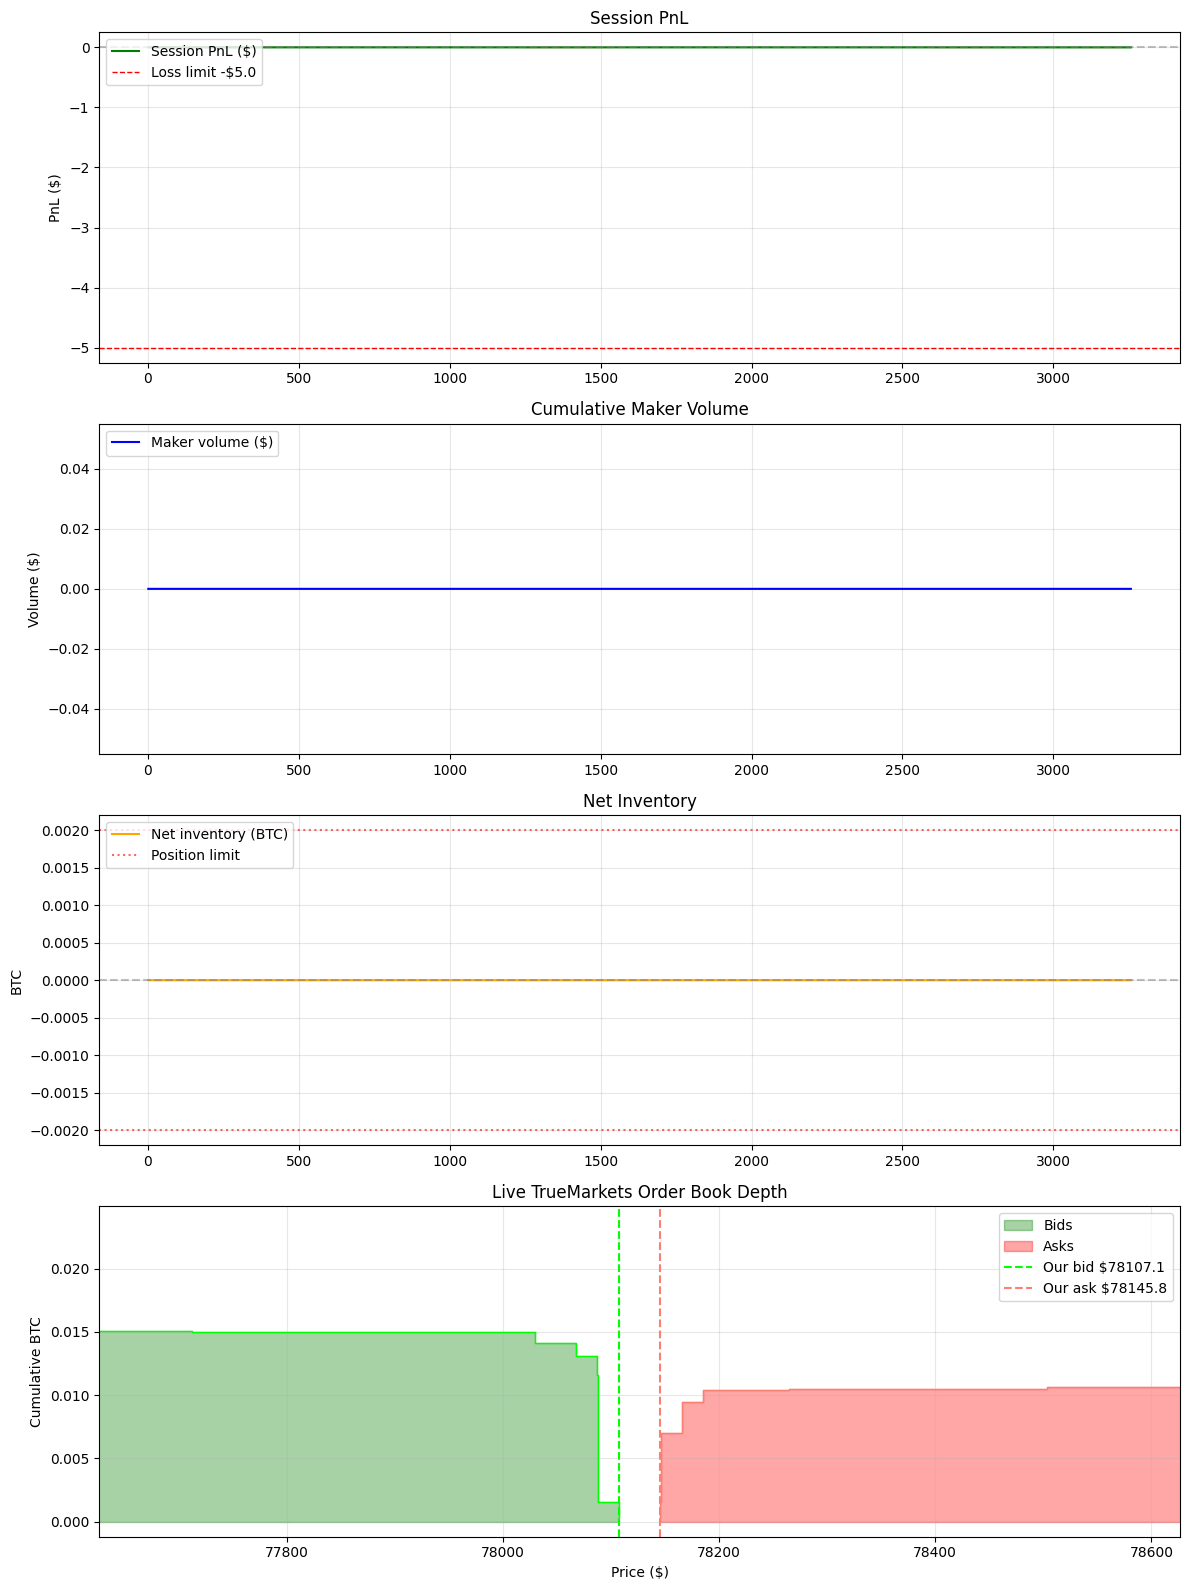

  16:53:10  book 78107.1[0.0004]/78145.8[0.0004]  spread $38.70  inv +0.00000  pnl $+0.0000  vol $0.00  rl 97/100
    bid: hold (we are BBO)  |  ask: hold (we are BBO)


ERROR:root:Coinbase WS: network error: [Errno 8] nodename nor servname provided, or not known. Reconnecting in 2s...
ERROR:root:Coinbase WS: network error: [Errno 8] nodename nor servname provided, or not known. Reconnecting in 4s...
ERROR:root:Coinbase WS: network error: [Errno 8] nodename nor servname provided, or not known. Reconnecting in 8s...


TrueMarketsBook error: [Errno 8] nodename nor servname provided, or not known
TM feed: bad/ERROR node, cycling load balancer (attempt 1)...
TrueMarketsBook error: [Errno 8] nodename nor servname provided, or not known
TrueMarketsBook error: [Errno 8] nodename nor servname provided, or not known
TrueMarketsBook error: [Errno 8] nodename nor servname provided, or not known
TrueMarketsBook error: [Errno 8] nodename nor servname provided, or not known


ERROR:root:Coinbase WS: network error: [Errno 8] nodename nor servname provided, or not known. Reconnecting in 16s...


TrueMarketsBook error: [Errno 8] nodename nor servname provided, or not known
TrueMarketsBook error: [Errno 8] nodename nor servname provided, or not known
TrueMarketsBook error: [Errno 8] nodename nor servname provided, or not known
TrueMarketsBook error: [Errno 8] nodename nor servname provided, or not known
TrueMarketsBook error: [Errno 8] nodename nor servname provided, or not known
TM feed: bad/ERROR node, cycling load balancer (attempt 10)...
TrueMarketsBook error: [Errno 8] nodename nor servname provided, or not known
TrueMarketsBook error: [Errno 8] nodename nor servname provided, or not known
TrueMarketsBook error: [Errno 8] nodename nor servname provided, or not known
TrueMarketsBook error: [Errno 8] nodename nor servname provided, or not known
TrueMarketsBook error: [Errno 8] nodename nor servname provided, or not known
TrueMarketsBook error: [Errno 8] nodename nor servname provided, or not known
TrueMarketsBook error: [Errno 8] nodename nor servname provided, or not known
T

ClientConnectorError: Cannot connect to host api.truemarkets.co:443 ssl:default [None]

In [6]:
# Interrupt kernel (stop button) to exit cleanly — all orders are cancelled on the way out
await run_strategy()